In [20]:
import pandas as pd 
import numpy as np 
import os 

In [21]:
framesFake={"Folder":[],"FrameCount":[],"File Path":[],"Label":[]}
for folder in os.listdir('fake/frames'):
    countFrame=0
    for frames in os.listdir(f'fake/frames/{folder}'):
        countFrame+=1
    framesFake["Folder"].append(folder)
    framesFake["FrameCount"].append(countFrame)
    framesFake['File Path'].append(f"fake/frames/{folder}")
    framesFake["Label"].append(0)

fakeFramesDF=pd.DataFrame(framesFake)
print(fakeFramesDF.shape)
fakeFramesDF.head(50)

(49, 4)


,Folder,FrameCount,File Path,Label
0,0000_fake,32,fake/frames/0000_fake,0
1,0001_fake,32,fake/frames/0001_fake,0
2,0002_fake,32,fake/frames/0002_fake,0
3,0003_fake,32,fake/frames/0003_fake,0
4,0004_fake,32,fake/frames/0004_fake,0
5,0005_fake,1,fake/frames/0005_fake,0
6,0006_fake,32,fake/frames/0006_fake,0
7,0007_fake,32,fake/frames/0007_fake,0
8,0008_fake,32,fake/frames/0008_fake,0
9,0009_fake,32,fake/frames/0009_fake,0


In [22]:
framesReal={"Folder":[],"FrameCount":[],"File Path":[],"Label":[]}
for folder in os.listdir('real/frames'):
    countFrame=0
    for frames in os.listdir(f'real/frames/{folder}'):
        countFrame+=1
    framesReal["Folder"].append(folder)
    framesReal["FrameCount"].append(countFrame)
    framesReal['File Path'].append(f"real/frames/{folder}")
    framesReal["Label"].append(1)

realFramesDF=pd.DataFrame(framesReal)
print(realFramesDF.shape)
realFramesDF.head(50)

(49, 4)


,Folder,FrameCount,File Path,Label
0,0000,32,real/frames/0000,1
1,0001,32,real/frames/0001,1
2,0002,32,real/frames/0002,1
3,0003,32,real/frames/0003,1
4,0004,32,real/frames/0004,1
5,0005,29,real/frames/0005,1
6,0006,32,real/frames/0006,1
7,0007,32,real/frames/0007,1
8,0008,32,real/frames/0008,1
9,0009,32,real/frames/0009,1


In [23]:
fakeFramesDF=fakeFramesDF[fakeFramesDF["FrameCount"]>=32]
realFramesDF=realFramesDF[realFramesDF['FrameCount']>=32]

print(fakeFramesDF.shape,realFramesDF.shape)



(45, 4) (44, 4)


In [24]:
df=pd.concat([fakeFramesDF,realFramesDF],ignore_index=True)
print(df.shape)

(89, 4)


In [27]:
from sklearn.model_selection import train_test_split

train,val=train_test_split(df,test_size=0.1,stratify=df['Label'],random_state=42)

In [28]:
print(train.shape,val.shape,sep=" ")

(80, 4) (9, 4)


In [35]:
import tensorflow as tf 

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.1,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 3072 files belonging to 2 classes.
Using 2458 files for training.
Found 3072 files belonging to 2 classes.
Using 307 files for validation.


In [40]:
print(train_ds.class_names)

['fake', 'real']


In [41]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [43]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

c:\Users\Sk Tajuddin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.6721 - loss: 0.6177 - val_accuracy: 0.8697 - val_loss: 0.3077
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9357 - loss: 0.1711 - val_accuracy: 0.9609 - val_loss: 0.1284
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9687 - loss: 0.1032 - val_accuracy: 0.9609 - val_loss: 0.0681
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9715 - loss: 0.0808 - val_accuracy: 0.9739 - val_loss: 0.0568
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9752 - loss: 0.0701 - val_accuracy: 0.9805 - val_loss: 0.0436
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.9780 - loss: 0.0657 - val_accuracy: 0.9642 - val_loss: 0.0944
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9703 - loss: 0.0770 - val_accuracy: 0.9707 - val_loss: 0.0518
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9768 - loss: 0.0653 - val_accuracy: 0.9837 - v

In [46]:
print(model.evaluate(val_ds))

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 307ms/step - accuracy: 0.9870 - loss: 0.0388
[0.038818977773189545, 0.9869706630706787]


In [47]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [53]:
accuracy=history.history["accuracy"]
val_accuracy=history.history["val_accuracy"]

print(accuracy[-1])
print(val_accuracy[-1])

0.980065107345581
0.9869706630706787


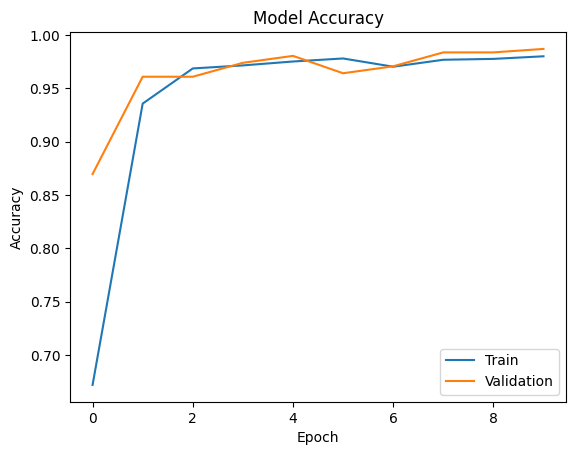

In [49]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()